In [ ]:
# installing kaggle library
! pip install kaggle

## Upload Kaggle JSON File

In [ ]:
# configuring the path of kaggle.json file
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


## Import Twitter Sentiment dataset

In [ ]:
#API to fetch the dataset from kaggle
!kaggle datasets download -d kazanova/sentiment140 --unzip

Dataset URL: https://www.kaggle.com/datasets/kazanova/sentiment140
License(s): other
100% 80.9M/80.9M [00:01<00:00, 53.0MB/s]



In [ ]:
# LOAD DATASET

import pandas as pd
columns = ['target', 'id', 'date', 'flag', 'user', 'tweet']
twitter_data = pd.read_csv(
    '/content/training.1600000.processed.noemoticon.csv',
    encoding='latin-1',
    names=columns)
twitter_data = twitter_data.sample(n=50000, random_state=42) #sample size taken 50,000 and randomly

twitter_data.head()

,target,id,date,flag,user,tweet
541200,0,2200003196,Tue Jun 16 18:18:12 PDT 2009,NO_QUERY,LaLaLindsey0609,@chrishasboobs AHHH I HOPE YOUR OK!!!
750,0,1467998485,Mon Apr 06 23:11:14 PDT 2009,NO_QUERY,sexygrneyes,"@misstoriblack cool , i have no tweet apps fo..."
766711,0,2300048954,Tue Jun 23 13:40:11 PDT 2009,NO_QUERY,sammydearr,@TiannaChaos i know just family drama. its la...
285055,0,1993474027,Mon Jun 01 10:26:07 PDT 2009,NO_QUERY,Lamb_Leanne,School email won't open and I have geography ...
705995,0,2256550904,Sat Jun 20 12:56:51 PDT 2009,NO_QUERY,yogicerdito,upper airways problem


## IMPORTING THE DEPENDENCIES

In [ ]:
import numpy as np
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [ ]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
# printing the stopwatch in English
print(stopwords.words('english'))  # stopwords are words that do not have much contextual importance

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

## Data Preprocessing

In [ ]:
# finding data shape
twitter_data.shape

(50000, 6)

In [ ]:
# counting no. of missing values in the dataset
twitter_data.isnull().sum()

,0
target,0
id,0
date,0
flag,0
user,0
tweet,0


In [ ]:
#checking distribution of target column
twitter_data['target'].value_counts()

,count
target,
4,25014
0,24986


In [ ]:
# convert target 4 to 1
twitter_data.replace({"target":{4:1}},inplace=True)
twitter_data['target'].value_counts()

,count
target,
1,25014
0,24986


0 - Negative tweet
 & 1 - Positive tweet

## Stemming (process of reducing a word to its root/base word)

In [ ]:
port_stem=PorterStemmer()

In [ ]:
def stemming(content):
  stemmed_content=re.sub('[^a-zA-Z]',' ',content) #remove all other symbols except aplhabet
  stemmed_content=stemmed_content.lower()         #lowercase converted
  stemmed_content=stemmed_content.split()         #[---]
  stemmed_content_content=[port_stem.stem(word) for word in stemmed_content if not word in stopwords.words('english')] #remove stopwords
  stemmed_content=' '.join(stemmed_content_content)
  return stemmed_content

In [ ]:
twitter_data.columns

Index(['target', 'id', 'date', 'flag', 'user', 'tweet'], dtype='object')

In [ ]:
twitter_data['stemmed_content']=twitter_data['tweet'].apply(stemming)

In [ ]:
twitter_data.head()

,target,id,date,flag,user,tweet,stemmed_content
541200,0,2200003196,Tue Jun 16 18:18:12 PDT 2009,NO_QUERY,LaLaLindsey0609,@chrishasboobs AHHH I HOPE YOUR OK!!!,chrishasboob ahhh hope ok
750,0,1467998485,Mon Apr 06 23:11:14 PDT 2009,NO_QUERY,sexygrneyes,"@misstoriblack cool , i have no tweet apps fo...",misstoriblack cool tweet app razr
766711,0,2300048954,Tue Jun 23 13:40:11 PDT 2009,NO_QUERY,sammydearr,@TiannaChaos i know just family drama. its la...,tiannachao know famili drama lame hey next tim...
285055,0,1993474027,Mon Jun 01 10:26:07 PDT 2009,NO_QUERY,Lamb_Leanne,School email won't open and I have geography ...,school email open geographi stuff revis stupid...
705995,0,2256550904,Sat Jun 20 12:56:51 PDT 2009,NO_QUERY,yogicerdito,upper airways problem,upper airway problem


In [ ]:
print(twitter_data['stemmed_content'])

541200                            chrishasboob ahhh hope ok
750                       misstoriblack cool tweet app razr
766711    tiannachao know famili drama lame hey next tim...
285055    school email open geographi stuff revis stupid...
705995                                 upper airway problem
                                ...                        
199266                          way home tire wanna babysit
210814    well ten sneez row allergi make day easi still...
180674                   go tonight car act funni wat shall
364859                                          headacheeee
172400                         tommcfli guy come fuck freez
Name: stemmed_content, Length: 50000, dtype: object


In [ ]:
print(twitter_data['target'].value_counts())

target
1    25014
0    24986
Name: count, dtype: int64


In [ ]:
#separating data and label
x=twitter_data['stemmed_content'].values
y=twitter_data['target'].values

In [ ]:
print(x)

['chrishasboob ahhh hope ok' 'misstoriblack cool tweet app razr'
 'tiannachao know famili drama lame hey next time u hang kim n u guy like sleepov whatev ill call u'
 ... 'go tonight car act funni wat shall' 'headacheeee'
 'tommcfli guy come fuck freez']


In [ ]:
print(y)

[0 0 0 ... 0 0 0]


## Splitting data into train and test

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,stratify=y,random_state=2)

In [ ]:
print(x.shape,x_train.shape,x_test.shape)

(50000,) (40000,) (10000,)


In [ ]:
# TF-IDF
vectorizer = TfidfVectorizer()

x_train = vectorizer.fit_transform(x_train)
x_test = vectorizer.transform(x_test)

In [ ]:
print(x_train)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 295713 stored elements and shape (40000, 40453)>
  Coords	Values
  (0, 19086)	0.5445070117619606
  (0, 39809)	0.26511451687678095
  (0, 19250)	0.2202553135670754
  (0, 22905)	0.30460054758534866
  (0, 38193)	0.2183272260590004
  (0, 31747)	0.2686727705484157
  (0, 22001)	0.4987486631629831
  (0, 11731)	0.35118434768620294
  (1, 24869)	0.3638791181184296
  (1, 3157)	0.21601101583623214
  (1, 14079)	0.3638791181184296
  (1, 39232)	0.16828914541367215
  (1, 28338)	0.20314838330964405
  (1, 3368)	0.3101679085024557
  (1, 27783)	0.242483225048072
  (1, 37767)	0.3136840682113977
  (1, 21050)	0.13356664290654574
  (1, 24854)	0.3503476726085968
  (1, 20816)	0.1432626667336583
  (1, 16075)	0.2683598872795558
  (1, 24380)	0.3638791181184296
  (2, 34373)	0.45912566630957685
  (2, 13531)	0.16331265713179455
  (2, 21187)	0.45912566630957685
  (2, 14176)	0.2097231309044216
  :	:
  (39997, 39196)	0.23773235658895825
  (39997, 36608)	0.4089

In [ ]:
print(x_test)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 67380 stored elements and shape (10000, 40453)>
  Coords	Values
  (0, 24706)	0.8663671221939462
  (0, 39078)	0.4994076587131797
  (1, 13426)	0.2242737710404623
  (1, 16074)	0.2851675775730722
  (1, 26276)	0.6657654844691729
  (1, 32151)	0.5241154666564042
  (1, 33911)	0.38786598926106314
  (2, 25363)	1.0
  (3, 4887)	0.4055134179701946
  (3, 21593)	0.4870506980822534
  (3, 29368)	0.5350391690317992
  (3, 32778)	0.3274571060043685
  (3, 35858)	0.2655643388004175
  (3, 39897)	0.36649829280669605
  (4, 13933)	0.8410879532668246
  (4, 14634)	0.540898377580691
  (5, 4569)	0.7617053432057316
  (5, 5281)	0.6479235835589244
  (6, 14351)	0.731677827027756
  (6, 25867)	0.4817992647530322
  (6, 38193)	0.482200192782395
  (7, 8249)	1.0
  (8, 15410)	1.0
  (9, 4707)	0.40016029513643014
  (9, 7368)	0.47111349573351907
  :	:
  (9997, 14072)	0.23318761475569885
  (9997, 14655)	0.3600410739118251
  (9997, 16420)	0.37478897165779634
  (9997, 25

## TRAINING MACHINE LEARNING MODEL

## LOGISTIC REGRESSION

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

## Accuracy score

In [ ]:
x_train_prediction=model.predict(x_train)
training_data_accuracy=accuracy_score(y_train,x_train_prediction)

In [ ]:
print("Accuracy score on the training data:",training_data_accuracy)

Accuracy score on the training data: 0.834075


In [ ]:
x_test_prediction = model.predict(x_test)
test_data_accuracy = accuracy_score(y_test, x_test_prediction)
print("Test Accuracy:", test_data_accuracy)

Test Accuracy: 0.756


In [ ]:
print("Precision:", precision_score(y_test,x_test_prediction))
print("Recall:", recall_score(y_test, x_test_prediction))
print("F1 Score:", f1_score(y_test, x_test_prediction))

print(confusion_matrix(y_test,x_test_prediction))

Precision: 0.7454510630147482
Recall: 0.7779332400559664
F1 Score: 0.7613458528951487
[[3668 1329]
 [1111 3892]]


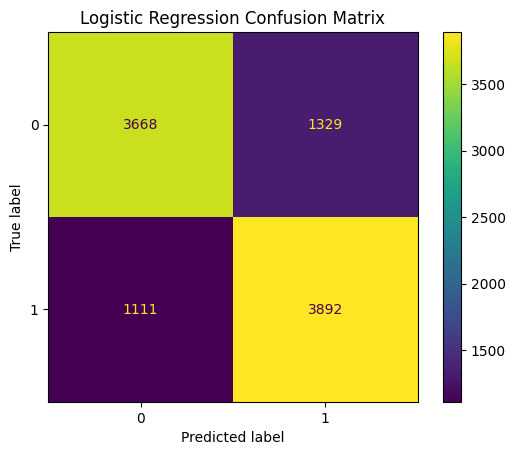

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, x_test_prediction)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

True Negative=3668, False Positive=1329, False Negative=1111, True Positive=3892
Overall, the Logistic Regression model performs well for binary sentiment classification. It correctly predicts most positive and negative tweets, although a small number of tweets are misclassified due to ambiguous wording, sarcasm, informal language, abbreviations, or limited contextual information.

## Naive Bayes

In [ ]:
from sklearn.naive_bayes import MultinomialNB
nb_model = MultinomialNB()
nb_model.fit(x_train, y_train)
nb_prediction = nb_model.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_prediction))
print("Precision:", precision_score(y_test, nb_prediction))
print("Recall:", recall_score(y_test, nb_prediction))
print("F1 Score:", f1_score(y_test, nb_prediction))
print(classification_report(y_test, nb_prediction))
print(confusion_matrix(y_test, nb_prediction))

Naive Bayes Accuracy: 0.7407
Precision: 0.76298559580969
Recall: 0.6987807315610634
F1 Score: 0.7294731351069379
              precision    recall  f1-score   support

           0       0.72      0.78      0.75      4997
           1       0.76      0.70      0.73      5003

    accuracy                           0.74     10000
   macro avg       0.74      0.74      0.74     10000
weighted avg       0.74      0.74      0.74     10000

[[3911 1086]
 [1507 3496]]


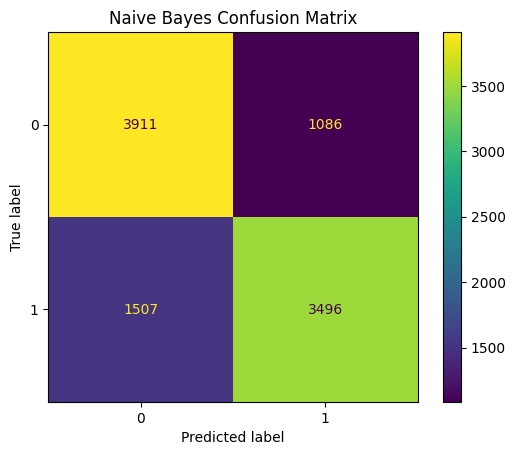

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, nb_prediction)

plt.title("Naive Bayes Confusion Matrix")
plt.show()

True negative=3911, False Positive=1086,False Negative=1507,True Positive=3496
The model correctly classified 7,407 tweets out of 10,000.
It identified negative tweets better than positive tweets.
Overall, Naive Bayes achieved good performance but was less accurate than Logistic Regression.

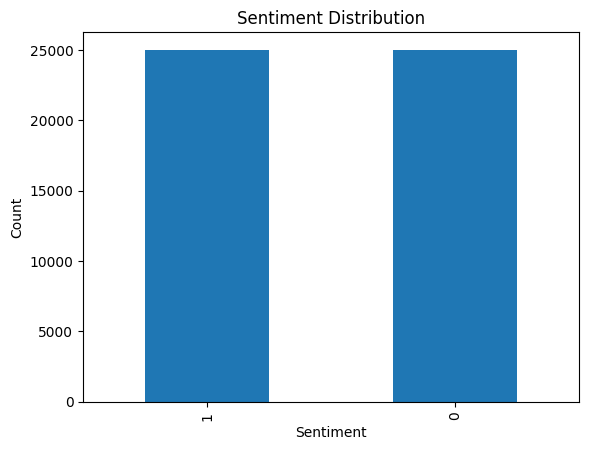

In [ ]:
import matplotlib.pyplot as plt

twitter_data['target'].value_counts().plot(kind='bar')

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

The two classes are almost equally distributed.
Since the dataset is balanced, there is no significant class imbalance, which helps improve the reliability of the machine learning models.

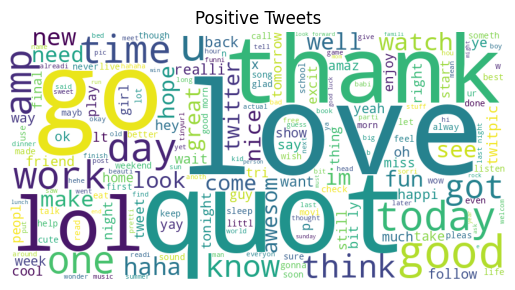

In [ ]:
!pip install wordcloud
from wordcloud import WordCloud
positive_text = " ".join(twitter_data[twitter_data['target']==1]['stemmed_content'])
wordcloud = WordCloud(width=800,height=400,background_color='white').generate(positive_text)
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Positive Tweets")
plt.show()

This represents the most frequently used words in positive tweets like love,good,lol,thank etc.The WordCloud suggests that positive tweets often express gratitude, enjoyment, and favorable experiences.

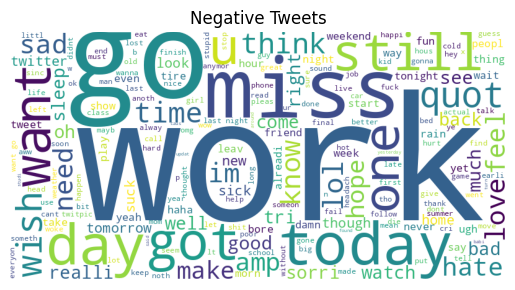

In [ ]:
negative_text = " ".join(twitter_data[twitter_data['target']==0]['stemmed_content'])
wordcloud = WordCloud(width=800,height=400,background_color='white').generate(negative_text)
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Negative Tweets")
plt.show()

This shows most common words in negative tweets like bad, hate, work,miss etc.The visualization indicates that many negative tweets relate to work pressure, tiredness, missed events, or dissatisfaction.